In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# A molecule with two places to lose a proton (Figures 13.6-1 and 13.6-2, Illustration 13.6-1)

Phthalic acid has two carboxyl groups on one benzene ring. They do not come off together,
and they do not come off at the same pH: p$K_1=2.95$ and p$K_2=5.41$. Between those two
values the molecule is mostly in a state that exists only *because* there are two groups
-- the singly ionized HA$^-$, which is neither the acid nor the fully dissociated anion.

Section 13.6 sets this up as the introduction to proteins, and that is the right way to
read it. A protein has 32 such groups instead of two; the algebra is identical and only
the bookkeeping grows.

$$\mathrm{H_2A}\rightleftharpoons\mathrm{H^+}+\mathrm{HA^-}\qquad
\mathrm{HA^-}\rightleftharpoons\mathrm{H^+}+\mathrm{A^{2-}}$$

**The key move is to treat pH as known.** The solution's acidity is being set by something
else -- a strong acid or base added, or a buffer -- so the question is not "what is the
pH" but "given the pH, what fraction of the acid is in each state". That makes the whole
problem linear.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import PolyproticAcid
from thermo.charts import use_book_style

use_book_style()

phthalic = PolyproticAcid([2.95, 5.41])        # Sec. 13.6's values
pH = np.linspace(1.0, 8.0, 701)                # the axes of Figs. 13.6-1 and 13.6-2


## The three fractions

Total acid is $M_{\rm acid}=M_{\rm H_2A}+M_{\rm HA^-}+M_{\rm A^{2-}}$, and each of the
last two follows from the first through its equilibrium constant. Eq. 13.6-3 factors
$M_{\rm H_2A}$ out,

$$M_{\rm acid}=M_{\rm H_2A}\left(1+\frac{K_1}{M_{\rm H^+}}
 +\frac{K_1K_2}{M_{\rm H^+}^{2}}\right)$$

so the fractions are that expression's three terms, normalized (Eqs. 13.6-4a to 4c):

$$f_{\rm H_2A}=\frac{M_{\rm H^+}^{2}}{M_{\rm H^+}^{2}+K_1M_{\rm H^+}+K_1K_2}$$

with $K_1M_{\rm H^+}$ and $K_1K_2$ over the same denominator for the other two. Written
in p$K$s, every term is a power of ten and the whole thing is one line of arithmetic.

The module builds these in **log space** and subtracts the largest exponent before
raising 10 to it. The printed form is $10^{-2\mathrm{pH}}$ over a sum of terms of the same
size; at pH 15 that is $10^{-30}/10^{-30}$, and in double precision the result is fine but
the intermediate is close enough to the underflow floor to avoid.


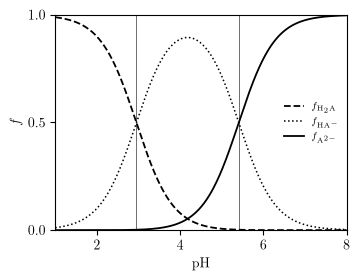

  at pH = pK1 = 2.95:  f = [0.4991 0.4991 0.0017]
  at pH = pK2 = 5.41:  f = [0.0017 0.4991 0.4991]

  at pK1 the first two fractions are equal; at pK2 the last two are.
  That is what a pK IS -- the pH at which two adjacent states are equally
  populated -- and it is the check that the fractions are assembled right.


In [3]:
f = phthalic.fractions(pH)

# Line styles follow the printed caption exactly: undissociated DASHED, singly ionized
# DOTTED, completely dissociated SOLID. Matching the art to the caption is one character;
# matching the caption to the art would have been a manuscript edit.
fig_1, ax = plt.subplots(figsize=(3.7, 2.9))
ax.plot(pH, f[0], "--", color="k", lw=1.3, label=r"$f_{\rm H_2A}$")
ax.plot(pH, f[1], ":", color="k", lw=1.1, label=r"$f_{\rm HA^-}$")
ax.plot(pH, f[2], "-", color="k", lw=1.3, label=r"$f_{\rm A^{2-}}$")
for p in phthalic.pKs:
    ax.axvline(p, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel(r"$f$")
ax.set_xlim(1, 8); ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1.0])
ax.legend(frameon=False, fontsize=7, loc="center right")
fig_1.tight_layout(); plt.show()

for p, name in zip(phthalic.pKs, ["pK1", "pK2"]):
    fr = phthalic.fractions(p)
    print(f"  at pH = {name} = {p}:  f = {np.array2string(fr, precision=4)}")
print("\n  at pK1 the first two fractions are equal; at pK2 the last two are.")
print("  That is what a pK IS -- the pH at which two adjacent states are equally")
print("  populated -- and it is the check that the fractions are assembled right.")


Figure 13.6-1's caption calls $f_{\rm HA^-}$ the **dotted** line, and the printed art
draws it dashed instead, with $f_{\rm H_2A}$ dashed as well and only the weight
distinguishing them. Two dashed curves of different weight is exactly the ambiguity the 6e
figure rules exist to prevent, so **the redraw above follows the caption**: dashed, dotted,
solid. The caption is printed text and the art is ours, so the art is what moves.

## The middle state never quite reaches one

The singly ionized form is a maximum, not a plateau. Illustration 13.6-1 finds where by
writing $f_{\rm HA^-}$ with its denominator in the form

$$f_{\rm HA^-}=\frac{1}{10^{\,\mathrm{p}K_1-\mathrm{pH}}+1+10^{\,\mathrm{pH}-\mathrm{p}K_2}}$$

-- one term that falls with pH, one constant, one that rises -- and setting the derivative
of the denominator to zero. The two exponentials are equal when
$2\mathrm{pH}=\mathrm{p}K_1+\mathrm{p}K_2$.

That maximum is **not** 1, and how far short it falls is a direct measure of how close the
two p$K$s are. For phthalic acid, $\Delta\mathrm{p}K=2.46$ and the peak is 0.895; make the
two groups more similar and the middle state stops being distinguishable at all.


In [4]:
pH_max = phthalic.pH_of_max(1)
print(f"  pH of maximum f_HA-  = (pK1 + pK2)/2 = {pH_max:.3f}   book: 4.18")
print(f"  the maximum itself   = {phthalic.fractions(pH_max)[1]:.4f}")

STAT = np.log10(4.0)        # the statistical separation of two identical sites
print(f"\n  {'dpK':>6} {'max f of the middle state':>28}")
for dpK in [0.0, STAT, 1.2, 2.46, 4.0, 6.0]:
    a = PolyproticAcid([4.18 - dpK / 2, 4.18 + dpK / 2])
    tag = ("   <- two identical independent sites" if abs(dpK - STAT) < 1e-9 else
           "   <- phthalic acid" if abs(dpK - 2.46) < 1e-9 else "")
    print(f"  {dpK:6.3f} {a.fractions(4.18)[1]:28.4f}{tag}")
print("\n  Two IDENTICAL sites are not dpK = 0.  A molecule with two equivalent groups")
print("  loses its first proton twice as easily (two ways to do it) and regains the")
print("  second twice as easily, so dpK = log10(4) = 0.602 -- and there the middle")
print("  state peaks at exactly 1/2.  dpK = 0 is unphysical for independent sites and")
print("  gives 1/3.  Phthalic acid's 2.46 is far above the statistical floor: the")
print("  second proton leaves an already-negative ion, and that is real interaction.")


  pH of maximum f_HA-  = (pK1 + pK2)/2 = 4.180   book: 4.18
  the maximum itself   = 0.8946

     dpK    max f of the middle state
   0.000                       0.3333
   0.602                       0.5000   <- two identical independent sites
   1.200                       0.6656
   2.460                       0.8946   <- phthalic acid
   4.000                       0.9804
   6.000                       0.9980

  Two IDENTICAL sites are not dpK = 0.  A molecule with two equivalent groups
  loses its first proton twice as easily (two ways to do it) and regains the
  second twice as easily, so dpK = log10(4) = 0.602 -- and there the middle
  state peaks at exactly 1/2.  dpK = 0 is unphysical for independent sites and
  gives 1/3.  Phthalic acid's 2.46 is far above the statistical floor: the
  second proton leaves an already-negative ion, and that is real interaction.


## The average charge, and why it is not an integer

Any single molecule of phthalic acid carries 0, $-1$ or $-2$. The *average* over the
population is the charge-weighted sum of the fractions,

$$\text{charge}=0\cdot f_{\rm H_2A}-1\cdot f_{\rm HA^-}-2\cdot f_{\rm A^{2-}}$$

and it runs smoothly between them. That average is what a measurement sees -- an
electrophoretic mobility, an ion-exchange retention time -- because those are population
averages too.


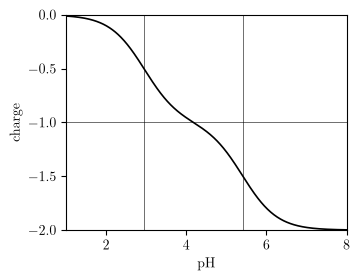

  pH  1.00   charge -0.0111
  pH  2.95   charge -0.5026
  pH  4.18   charge -1.0000
  pH  5.41   charge -1.4974
  pH  7.00   charge -1.9749
  pH  8.00   charge -1.9974

  the curve passes through exactly -1 at pH = 4.18, where the middle state
  peaks and the outer two are equally populated -- a plateau of one flat point.


In [5]:
fig_2, ax = plt.subplots(figsize=(3.7, 2.9))
ax.plot(pH, phthalic.charge(pH), "-", color="k", lw=1.2)
for p in phthalic.pKs:
    ax.axvline(p, color="k", lw=0.4, zorder=0)
ax.axhline(-1.0, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("charge")
ax.set_xlim(1, 8); ax.set_ylim(-2, 0)
ax.set_yticks([0, -0.5, -1.0, -1.5, -2.0])
fig_2.tight_layout(); plt.show()

for p in (1.0, 2.95, 4.18, 5.41, 7.0, 8.0):
    print(f"  pH {p:5.2f}   charge {float(phthalic.charge(p)):+.4f}")
print("\n  the curve passes through exactly -1 at pH = 4.18, where the middle state")
print("  peaks and the outer two are equally populated -- a plateau of one flat point.")


Illustration 13.6-1 says the acid is *"fully dissociated with a charge of $-2$"* at
pH 7. At pH 7 the charge is $-1.975$; it reaches $-1.99$ at pH 7.7 and $-2$ only
asymptotically. A small thing, but an average charge is by definition not
an integer, so rounding it to one in the sentence beneath the figure undercuts the figure.

## Where this is going

Nothing above used the fact that there were exactly two groups. `PolyproticAcid` takes any
number of p$K$s, which is what Problem 13.77 -- *"derive the equation that replaces
Eq. 13.6-3 for a protein that has six ionizable sites"* -- is asking for. The
generalization is a longer denominator and nothing else.

**The approximation buried in it** is that the groups are independent: the p$K$ of one
carboxyl does not depend on whether the other has already ionized. For phthalic acid that
is not quite true -- the second proton leaves a molecule that is already negative, which
is why p$K_2-\mathrm{p}K_1=2.46$ rather than the 0.6 that pure statistics would give for
two identical independent groups. The measured p$K$s absorb the interaction; the model
does not represent it.


  apparent pKs of six equivalent sites, intrinsic pK = 6:
    [5.222 5.602 5.875 6.125 6.398 6.778]


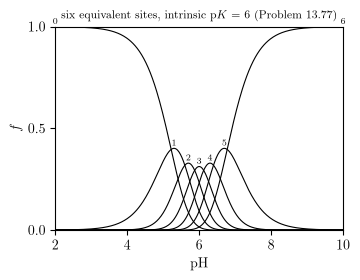


  fractions at pH = 6:  [0.0156 0.0938 0.2344 0.3125 0.2344 0.0938 0.0156]
  binomial / 2^6     :  [0.0156 0.0938 0.2344 0.3125 0.2344 0.0938 0.0156]
  charge at pH 6     :  -3.0000   (expected -3)

  Exactly the statistics of six coins -- which is what 'independent sites'
  means, and the baseline any real protein's charge curve departs from.


In [6]:
# six identical independent sites, as Problem 13.77 poses.
# For n equivalent sites of intrinsic pK = p, the successive APPARENT pKs are
# spread by statistics alone:  pK_j = p + log10( j / (n - j + 1) ).
def independent_sites(n, p):
    return PolyproticAcid([p + np.log10(j / (n - j + 1)) for j in range(1, n + 1)])

six = independent_sites(6, 6.0)
print("  apparent pKs of six equivalent sites, intrinsic pK = 6:")
print("   ", np.array2string(np.array(six.pKs), precision=3))

pH6 = np.linspace(2, 10, 401)
f6 = six.fractions(pH6)

fig, ax = plt.subplots(figsize=(3.7, 2.9))
for j in range(7):
    ax.plot(pH6, f6[j], "-", color="k", lw=0.8)
    jmax = pH6[f6[j].argmax()]
    ax.annotate(str(j), (jmax, f6[j].max()), textcoords="offset points",
                xytext=(0, 2), ha="center", fontsize=6)
ax.set_xlabel("pH"); ax.set_ylabel(r"$f$")
ax.set_xlim(2, 10); ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1.0])
ax.set_title("six equivalent sites, intrinsic p$K$ = 6 (Problem 13.77)", fontsize=8)
fig.tight_layout(); plt.show()

from math import comb
binomial = np.array([comb(6, j) for j in range(7)]) / 2 ** 6
print(f"\n  fractions at pH = 6:  {np.array2string(six.fractions(6.0), precision=4)}")
print(f"  binomial / 2^6     :  {np.array2string(binomial, precision=4)}")
assert np.allclose(six.fractions(6.0), binomial), "six independent coins, or a bug"
print(f"  charge at pH 6     :  {float(six.charge(6.0)):+.4f}   (expected -3)")
print("\n  Exactly the statistics of six coins -- which is what 'independent sites'")
print("  means, and the baseline any real protein's charge curve departs from.")


## The deliverable art

`Figure_13.6-1.pdf` and `Figure_13.6-2.pdf`, written at the book's figure size in Computer
Modern, pure black ink. The p$K$ guide lines and the charge $=-1$ line are **black hairlines**, not the gray they
were drafted in: 6e art is pure black ink on white, and families are separated by weight,
dash and geometry rather than by tint. The Problem 13.77 panel above is exploration and is
not staged.


In [7]:
os.makedirs("pdf", exist_ok=True)
for figure, name in ((fig_1, "Figure_13.6-1"), (fig_2, "Figure_13.6-2")):
    path = f"pdf/{name}.pdf"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")


  wrote pdf/Figure_13.6-1.pdf


  wrote pdf/Figure_13.6-2.pdf

  typography: LaTeX Computer Modern


## Your turn

1. Malonic acid has p$K_1$ = 2.83 and p$K_2$ = 5.69, and succinic acid 4.21 and 5.64.
   Plot the middle-state fraction for both against phthalic acid, and rank the three by
   how well-separated their two ionizations are.
2. Citric acid is triprotic (p$K$ = 3.13, 4.76, 6.40). Plot its four fractions and its
   average charge. At what pH is the doubly-ionized form most abundant, and does your
   answer match $({\rm p}K_2+{\rm p}K_3)/2$?
3. Show analytically that for $n$ **identical, independent** sites of p$K$ = $p$, the
   fraction with $j$ protons removed at pH = $p$ is $\binom{n}{j}/2^n$. Then explain why
   the successive apparent p$K$s of such a molecule are *not* all equal to $p$.
4. Recompute Fig. 13.6-2 with the ion activity coefficients included at $I=0.15$ M
   (physiological saline). Which of the two p$K$s moves further, and why should the one
   producing a divalent anion move more?
5. The section says an average charge "need not be an integer". Design a measurement that
   would distinguish a solution in which every molecule carries $-1$ from one in which
   half carry 0 and half carry $-2$. Both have the same average charge.
